# 6.10 - CertCF input vs latent benchmark analysis

This notebook analyzes the latest CertCF benchmark comparing two atlas subsampling variants under the same input-space CertCF pipeline:

- `certcf_input_kmedoids`: class-wise `k`-medoids in input space
- `certcf_latent_kmedoids`: class-wise `k`-medoids in penultimate latent space

The benchmark parquet is treated as the source of truth here. The goal is to summarize and visualize the last run cleanly, dataset by dataset, while keeping detailed methodological investigation in the earlier diagnostics notebooks.


In [2]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT_CANDIDATES = [Path.cwd(), Path.cwd().parent]
ROOT = None
for candidate in ROOT_CANDIDATES:
    if (candidate / 'src').exists() and (candidate / 'notebooks').exists():
        ROOT = candidate.resolve()
        break
if ROOT is None:
    raise RuntimeError('Could not resolve repository root from the current notebook location.')

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from notebooks.utils.io import load_result

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)


In [3]:
RESULT_PATH = ROOT / 'results/benchmark_meeting_certcf_input_vs_latent_200q.parquet'
METHOD_ORDER = ['certcf_input_kmedoids', 'certcf_latent_kmedoids']
METHOD_LABELS = {
    'certcf_input_kmedoids': 'CertCF input k-medoids',
    'certcf_latent_kmedoids': 'CertCF latent k-medoids',
}
DATASET_ORDER = ['adult', 'compas', 'german_credit', 'heloc', 'give_me_some_credit', 'lending_club']

print(RESULT_PATH)
print(METHOD_ORDER)


/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/results/benchmark_meeting_certcf_input_vs_latent_200q.parquet
['certcf_input_kmedoids', 'certcf_latent_kmedoids']


In [4]:
def _infer_dataset_from_params(params_raw: str) -> str | None:
    try:
        params = json.loads(params_raw) if isinstance(params_raw, str) else {}
    except json.JSONDecodeError:
        return None
    checkpoint = str(params.get('checkpoint', ''))
    if not checkpoint:
        return None
    stem = Path(checkpoint).stem
    prefix = stem.replace('_classifier', '').replace('best', '')
    if 'adult' in checkpoint:
        return 'adult'
    if 'compas' in checkpoint:
        return 'compas'
    if 'german_credit' in checkpoint:
        return 'german_credit'
    if 'heloc' in checkpoint:
        return 'heloc'
    if 'give_me_some_credit' in checkpoint:
        return 'give_me_some_credit'
    if 'lending_club' in checkpoint:
        return 'lending_club'
    return prefix or None


def _ensure_dataset_column(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if 'dataset' not in out.columns:
        out['dataset'] = out['params'].map(_infer_dataset_from_params)
    else:
        missing = out['dataset'].isna()
        if missing.any():
            out.loc[missing, 'dataset'] = out.loc[missing, 'params'].map(_infer_dataset_from_params)
    out['dataset'] = pd.Categorical(out['dataset'], categories=DATASET_ORDER, ordered=True)
    out['method'] = pd.Categorical(out['method'], categories=METHOD_ORDER, ordered=True)
    return out


def _method_summary(df: pd.DataFrame) -> pd.DataFrame:
    valid = df[df['success']].copy()
    base = (
        df.groupby(['dataset', 'method'], observed=True, as_index=False)
        .agg(
            n_queries=('success', 'size'),
            valid=('success', 'sum'),
            valid_rate=('success', 'mean'),
            build_time_s=('build_time_s', 'mean'),
            query_time_s=('runtime_s', 'mean'),
        )
    )
    distances = (
        valid.groupby(['dataset', 'method'], observed=True, as_index=False)
        .agg(
            l1_mean=('l1_distance', 'mean'),
            l1_median=('l1_distance', 'median'),
            l2_mean=('l2_distance', 'mean'),
            sparsity_mean=('l0_sparsity', 'mean'),
        )
    )
    out = base.merge(distances, on=['dataset', 'method'], how='left')
    out['valid_pct'] = 100.0 * out['valid_rate']
    out['sparsity_pct'] = 100.0 * out['sparsity_mean']
    return out.sort_values(['dataset', 'method']).reset_index(drop=True)


def _dataset_deltas(summary_df: pd.DataFrame) -> pd.DataFrame:
    pivot = summary_df.pivot(index='dataset', columns='method')
    pivot.columns = [f"{metric}__{method}" for metric, method in pivot.columns]
    pivot = pivot.reset_index()
    pivot['delta_l1_latent_minus_input'] = pivot['l1_mean__certcf_latent_kmedoids'] - pivot['l1_mean__certcf_input_kmedoids']
    pivot['delta_query_time_latent_minus_input'] = pivot['query_time_s__certcf_latent_kmedoids'] - pivot['query_time_s__certcf_input_kmedoids']
    pivot['delta_build_time_latent_minus_input'] = pivot['build_time_s__certcf_latent_kmedoids'] - pivot['build_time_s__certcf_input_kmedoids']
    pivot['delta_l2_latent_minus_input'] = pivot['l2_mean__certcf_latent_kmedoids'] - pivot['l2_mean__certcf_input_kmedoids']
    pivot['delta_sparsity_pct_latent_minus_input'] = pivot['sparsity_pct__certcf_latent_kmedoids'] - pivot['sparsity_pct__certcf_input_kmedoids']
    return pivot


def _paired_query_summary(df: pd.DataFrame) -> pd.DataFrame:
    valid = df[df['success']].copy()
    paired = valid.pivot_table(
        index=['dataset', 'query_idx'],
        columns='method',
        values=['l1_distance', 'runtime_s'],
        aggfunc='first',
    )
    rows = []
    for dataset, grp in paired.groupby(level=0):
        input_l1 = grp[('l1_distance', 'certcf_input_kmedoids')]
        latent_l1 = grp[('l1_distance', 'certcf_latent_kmedoids')]
        input_rt = grp[('runtime_s', 'certcf_input_kmedoids')]
        latent_rt = grp[('runtime_s', 'certcf_latent_kmedoids')]
        rows.append({
            'dataset': dataset,
            'n_paired_queries': int(len(grp)),
            'latent_better_l1_share': float((latent_l1 < input_l1).mean()),
            'latent_better_runtime_share': float((latent_rt < input_rt).mean()),
            'mean_l1_delta_latent_minus_input': float((latent_l1 - input_l1).mean()),
            'mean_runtime_delta_latent_minus_input': float((latent_rt - input_rt).mean()),
        })
    return pd.DataFrame(rows).sort_values('dataset').reset_index(drop=True)


In [5]:
df = load_result(RESULT_PATH, method_labels=METHOD_LABELS)
df = _ensure_dataset_column(df)

availability_df = (
    df.groupby(['dataset', 'method'], observed=True, as_index=False)
    .agg(
        n_rows=('success', 'size'),
        valid=('success', 'sum'),
    )
)
availability_df['valid_pct'] = 100.0 * availability_df['valid'] / availability_df['n_rows']
display(availability_df.sort_values(['dataset', 'method']))

print('Loaded rows:', len(df))
print('Datasets:', [x for x in df['dataset'].dropna().astype(str).unique().tolist()])
print('Methods:', [x for x in df['method'].dropna().astype(str).unique().tolist()])


,dataset,method,n_rows,valid,valid_pct
0,adult,certcf_input_kmedoids,200,200,100.0
1,adult,certcf_latent_kmedoids,200,200,100.0
2,compas,certcf_input_kmedoids,200,200,100.0
3,compas,certcf_latent_kmedoids,200,200,100.0
4,german_credit,certcf_input_kmedoids,100,100,100.0
5,german_credit,certcf_latent_kmedoids,100,100,100.0


Loaded rows: 1000
Datasets: ['adult', 'compas', 'german_credit']
Methods: ['certcf_input_kmedoids', 'certcf_latent_kmedoids']


## 1. Method-level benchmark summary

This is the main headline table: one row per dataset and method, using the saved combined parquet directly.


In [6]:
summary_df = _method_summary(df)
display(
    summary_df[[
        'dataset', 'method', 'n_queries', 'valid_pct', 'l1_mean', 'l1_median', 'l2_mean', 'sparsity_pct', 'query_time_s', 'build_time_s'
    ]]
)


,dataset,method,n_queries,valid_pct,l1_mean,l1_median,l2_mean,sparsity_pct,query_time_s,build_time_s
0,adult,certcf_input_kmedoids,200,100.0,7.535339,7.378781,2.891657,8.096154,1.729555,9.818044
1,adult,certcf_latent_kmedoids,200,100.0,7.304791,7.297893,2.876938,7.615385,1.232939,17.075208
2,compas,certcf_input_kmedoids,200,100.0,1.704705,1.331026,1.256966,19.500000,0.138531,5.726805
3,compas,certcf_latent_kmedoids,200,100.0,1.413786,0.995307,1.056468,18.607143,0.087194,5.808194
4,german_credit,certcf_input_kmedoids,100,100.0,10.905355,10.593336,3.511016,18.508197,1.771893,5.662157
5,german_credit,certcf_latent_kmedoids,100,100.0,10.756576,10.601522,3.476322,18.327869,1.455689,5.877831


## 2. Latent minus input deltas

Negative deltas favor the latent selector for distance and runtime; positive deltas mean latent is worse on that metric.


In [7]:
delta_df = _dataset_deltas(summary_df)
delta_cols = [
    'dataset',
    'delta_l1_latent_minus_input',
    'delta_l2_latent_minus_input',
    'delta_sparsity_pct_latent_minus_input',
    'delta_query_time_latent_minus_input',
    'delta_build_time_latent_minus_input',
]
display(delta_df[delta_cols].sort_values('dataset'))


,dataset,delta_l1_latent_minus_input,delta_l2_latent_minus_input,delta_sparsity_pct_latent_minus_input,delta_query_time_latent_minus_input,delta_build_time_latent_minus_input
0,adult,-0.230548,-0.014720,-0.480769,-0.496616,7.257163
1,compas,-0.290918,-0.200498,-0.892857,-0.051337,0.081389
2,german_credit,-0.148778,-0.034694,-0.180328,-0.316204,0.215674


## 3. Paired per-query comparison

This compares the two methods on the same query ids inside each dataset, using only shared successful queries.


In [8]:
paired_df = _paired_query_summary(df)
paired_df['latent_better_l1_pct'] = 100.0 * paired_df['latent_better_l1_share']
paired_df['latent_better_runtime_pct'] = 100.0 * paired_df['latent_better_runtime_share']
display(
    paired_df[[
        'dataset', 'n_paired_queries', 'latent_better_l1_pct', 'latent_better_runtime_pct', 'mean_l1_delta_latent_minus_input', 'mean_runtime_delta_latent_minus_input'
    ]]
)


/tmp/ipykernel_10247/2085551310.py:80: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  paired = valid.pivot_table(
/tmp/ipykernel_10247/2085551310.py:87: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for dataset, grp in paired.groupby(level=0):


,dataset,n_paired_queries,latent_better_l1_pct,latent_better_runtime_pct,mean_l1_delta_latent_minus_input,mean_runtime_delta_latent_minus_input
0,adult,200,61.0,65.5,-0.230548,-0.496616
1,compas,200,68.5,59.5,-0.290918,-0.051337
2,german_credit,100,24.0,80.0,-0.148778,-0.316204
3,give_me_some_credit,0,NaN,NaN,NaN,NaN
4,heloc,0,NaN,NaN,NaN,NaN
5,lending_club,0,NaN,NaN,NaN,NaN


## 4. Headline plots

These plots show the main benchmark tradeoffs at the dataset level.


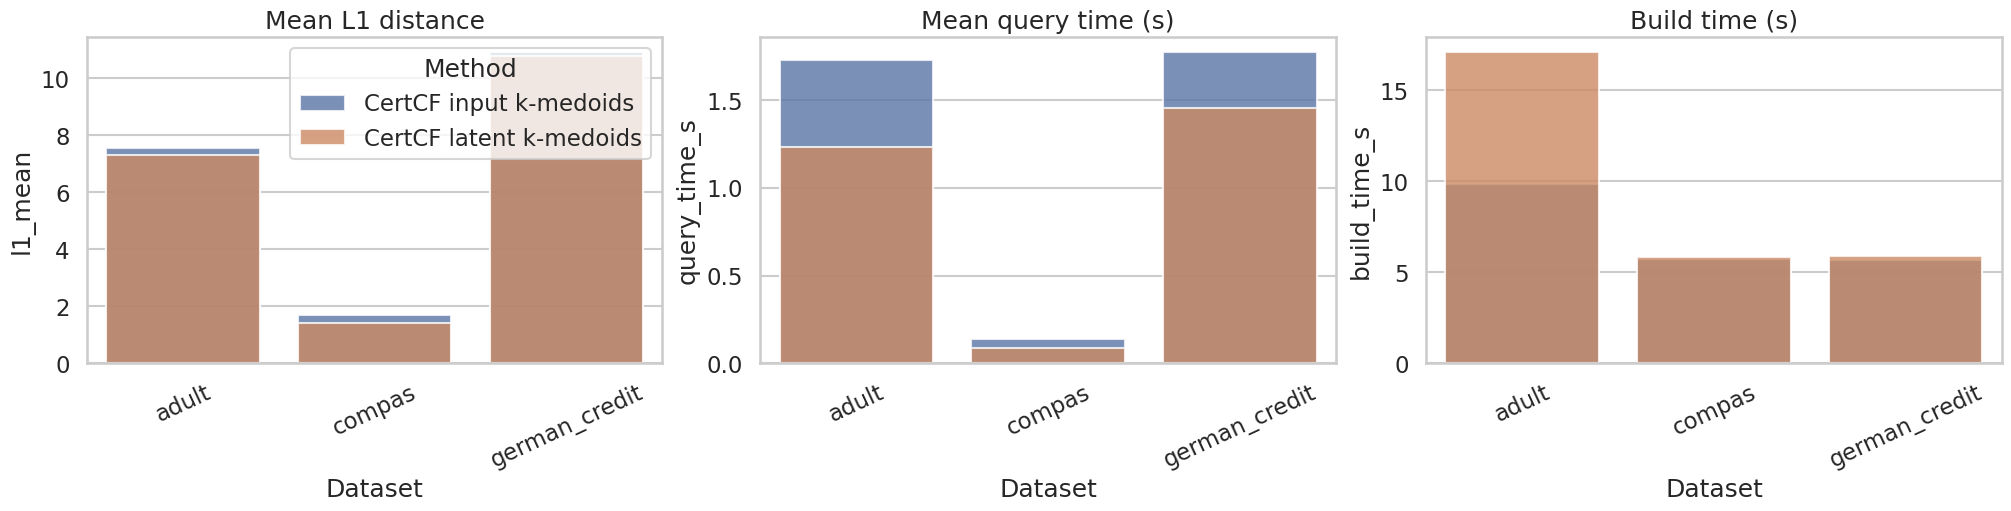

In [9]:
plot_df = summary_df.copy()
plot_df['method_label'] = plot_df['method'].map(METHOD_LABELS)

fig, axes = plt.subplots(1, 3, figsize=(20, 5), constrained_layout=True)
metrics = [
    ('l1_mean', 'Mean L1 distance'),
    ('query_time_s', 'Mean query time (s)'),
    ('build_time_s', 'Build time (s)'),
]
for ax, (metric, title) in zip(axes, metrics):
    sns.barplot(
        data=plot_df,
        x='dataset',
        y=metric,
        hue='method_label',
        order=[d for d in DATASET_ORDER if d in plot_df['dataset'].astype(str).tolist()],
        ax=ax,
        alpha=0.8,
    )
    ax.set_title(title)
    ax.set_xlabel('Dataset')
    ax.tick_params(axis='x', rotation=25)
    if ax is not axes[0]:
        ax.legend_.remove()
axes[0].legend(title='Method', loc='best')
plt.show()


## 5. Delta plots

These plots use latent-minus-input deltas, so values below zero indicate a latent-space advantage on the corresponding metric.


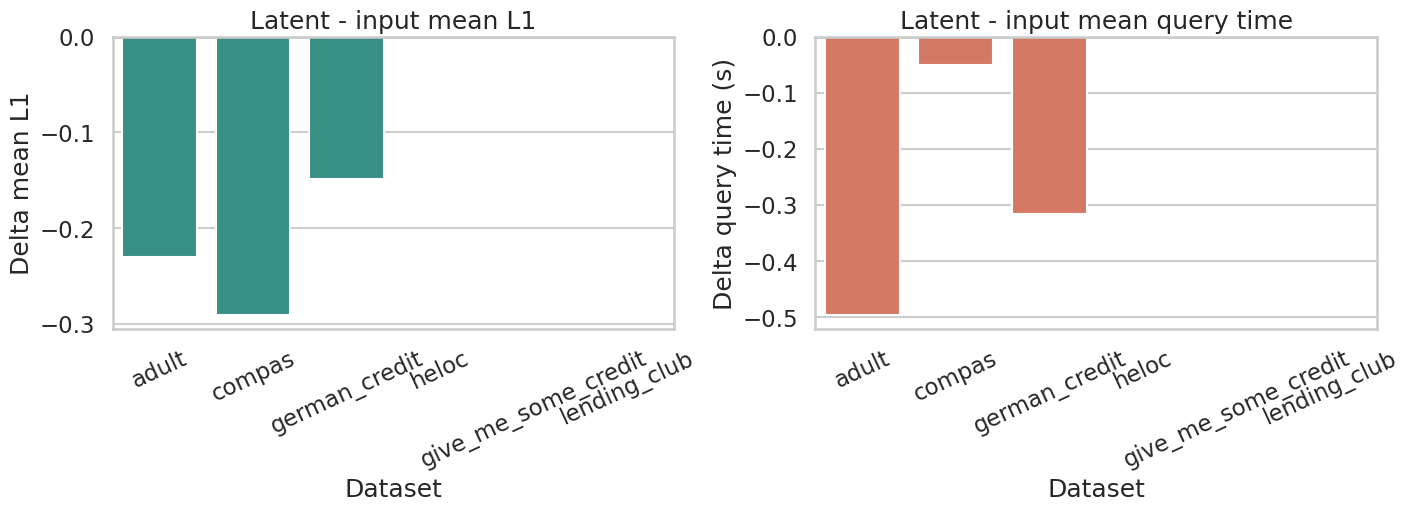

In [10]:
delta_plot_df = delta_df.copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.barplot(data=delta_plot_df, x='dataset', y='delta_l1_latent_minus_input', ax=axes[0], color='#2a9d8f')
axes[0].axhline(0.0, color='black', linewidth=1)
axes[0].set_title('Latent - input mean L1')
axes[0].set_xlabel('Dataset')
axes[0].set_ylabel('Delta mean L1')
axes[0].tick_params(axis='x', rotation=25)

sns.barplot(data=delta_plot_df, x='dataset', y='delta_query_time_latent_minus_input', ax=axes[1], color='#e76f51')
axes[1].axhline(0.0, color='black', linewidth=1)
axes[1].set_title('Latent - input mean query time')
axes[1].set_xlabel('Dataset')
axes[1].set_ylabel('Delta query time (s)')
axes[1].tick_params(axis='x', rotation=25)

plt.show()


## 6. Per-query scatter views

Each panel compares latent vs input on matched query ids. Points below the diagonal indicate a latent advantage.


/tmp/ipykernel_10247/956796813.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  paired = valid.pivot_table(


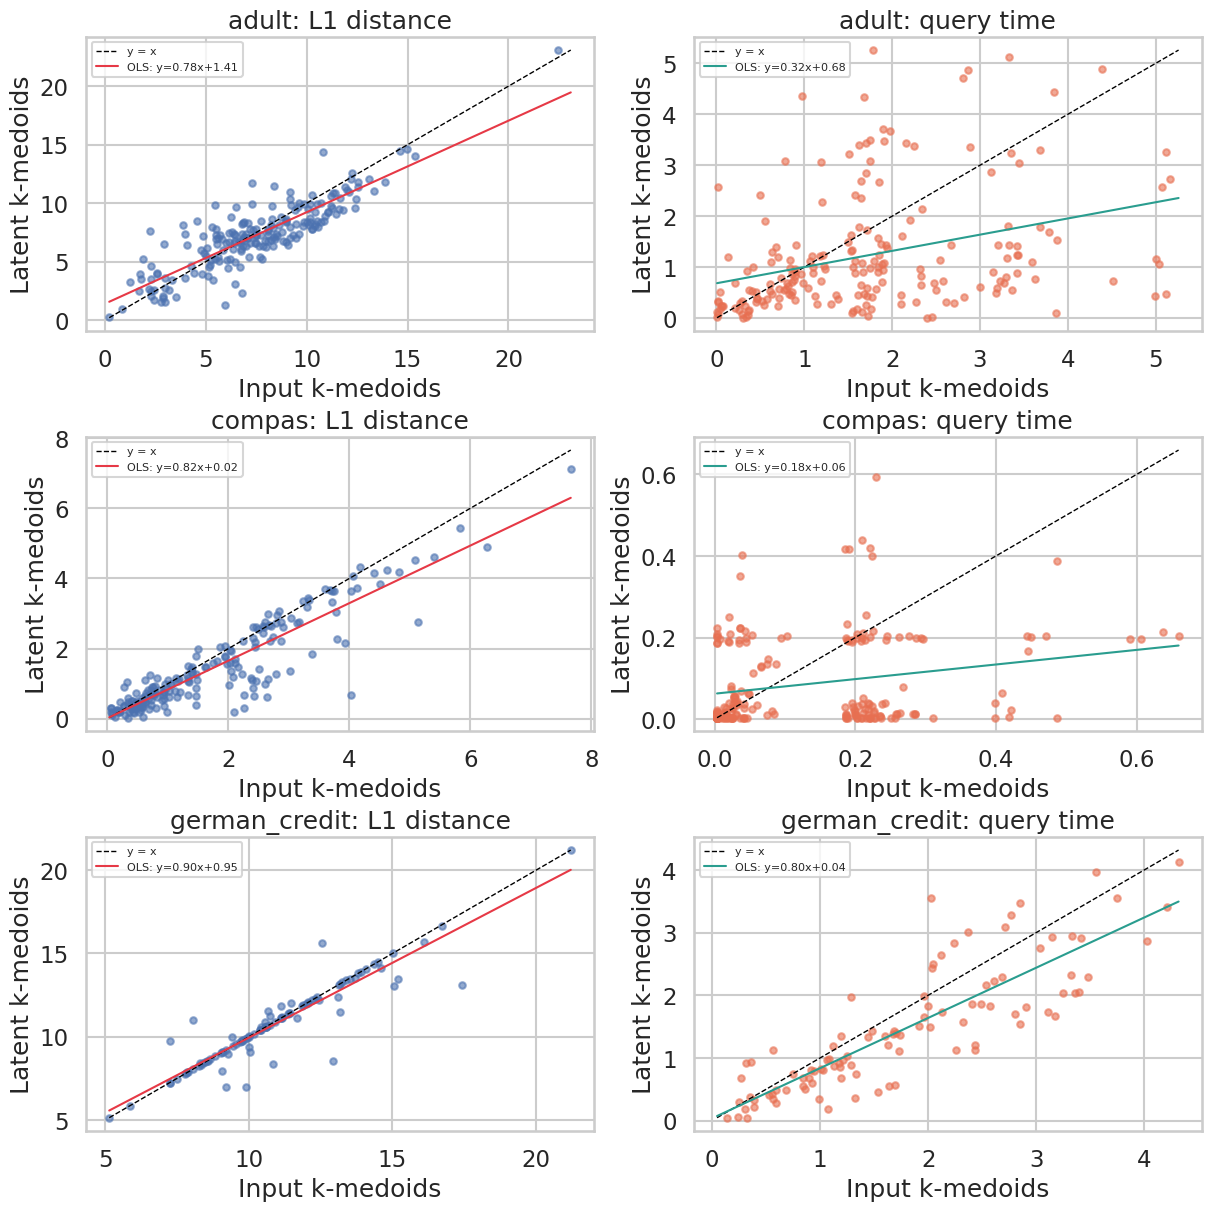

In [11]:
from scipy import stats

valid = df[df['success']].copy()
paired = valid.pivot_table(
    index=['dataset', 'query_idx'],
    columns='method',
    values=['l1_distance', 'runtime_s'],
    aggfunc='first',
)

datasets_present = [d for d in DATASET_ORDER if d in valid['dataset'].astype(str).tolist()]
fig, axes = plt.subplots(len(datasets_present), 2, figsize=(12, 4 * max(1, len(datasets_present))), constrained_layout=True)
if len(datasets_present) == 1:
    axes = np.array([axes])

for row_idx, dataset_name in enumerate(datasets_present):
    grp = paired.loc[dataset_name]
    x_l1 = grp[('l1_distance', 'certcf_input_kmedoids')]
    y_l1 = grp[('l1_distance', 'certcf_latent_kmedoids')]
    x_rt = grp[('runtime_s', 'certcf_input_kmedoids')]
    y_rt = grp[('runtime_s', 'certcf_latent_kmedoids')]

    ax0, ax1 = axes[row_idx]

    # L1 scatter
    ax0.scatter(x_l1, y_l1, alpha=0.6, s=22)
    lim0 = [min(x_l1.min(), y_l1.min()), max(x_l1.max(), y_l1.max())]
    ax0.plot(lim0, lim0, linestyle='--', color='black', linewidth=1, label='y = x')

    # Linear regression on L1
    valid_mask_l1 = x_l1.notna() & y_l1.notna()
    if valid_mask_l1.sum() >= 2:
        slope0, intercept0, *_ = stats.linregress(x_l1[valid_mask_l1], y_l1[valid_mask_l1])
        x_range0 = np.linspace(lim0[0], lim0[1], 200)
        ax0.plot(x_range0, slope0 * x_range0 + intercept0, color='#e63946', linewidth=1.5,
                 label=f'OLS: y={slope0:.2f}x+{intercept0:.2f}')
    ax0.legend(fontsize=8, loc='upper left')
    ax0.set_title(f'{dataset_name}: L1 distance')
    ax0.set_xlabel('Input k-medoids')
    ax0.set_ylabel('Latent k-medoids')

    # Runtime scatter
    ax1.scatter(x_rt, y_rt, alpha=0.6, s=22, color='#e76f51')
    lim1 = [min(x_rt.min(), y_rt.min()), max(x_rt.max(), y_rt.max())]
    ax1.plot(lim1, lim1, linestyle='--', color='black', linewidth=1, label='y = x')

    # Linear regression on runtime
    valid_mask_rt = x_rt.notna() & y_rt.notna()
    if valid_mask_rt.sum() >= 2:
        slope1, intercept1, *_ = stats.linregress(x_rt[valid_mask_rt], y_rt[valid_mask_rt])
        x_range1 = np.linspace(lim1[0], lim1[1], 200)
        ax1.plot(x_range1, slope1 * x_range1 + intercept1, color='#2a9d8f', linewidth=1.5,
                 label=f'OLS: y={slope1:.2f}x+{intercept1:.2f}')
    ax1.legend(fontsize=8, loc='upper left')
    ax1.set_title(f'{dataset_name}: query time')
    ax1.set_xlabel('Input k-medoids')
    ax1.set_ylabel('Latent k-medoids')

plt.show()


## 7. Notes

- This notebook reads the saved benchmark parquet as-is, rather than rebuilding anything.
- If `dataset` is missing in an older parquet, the notebook falls back to parsing the checkpoint path stored in `params`.
- The benchmark summary metric here is the benchmark `l1_distance`, not the pilot `result.distance` used in the earlier CertCF diagnostics notebooks.
